## 数据输入模块
- 生成100x100平面内的30个城市，计算距离矩阵，计算路径总长度

In [1]:
# 首先导入必要的库
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import matplotlib.animation as animation
import time
import pandas as pd
from tqdm.notebook import tqdm
import multiprocess as mp
import itertools

# 固定随机数种子
np.random.seed(42)
random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

#### _cities 函数：在 grid * grid 的平面内随机生成 num 个点城市坐标

In [2]:
def _cities(num =30, grid =100):
    """
    在 grid * grid 的平面内随机生成 num 个点城市坐标
    """
    cities = np.random.rand(num, 2) * grid
    return cities

#### _dist_mat 函数：计算任意两座城市之间的欧氏距离并存储在矩阵中

In [3]:
def _dist_mat(cities):
    """
    计算城市之间的欧式距离矩阵
    """
    num = len(cities)
    dist_mat = np.zeros((num, num))
    for i in range(num):
        for j in range(num):
            if i != j:
                dist_mat[i][j] = np.linalg.norm(cities[i] - cities[j])
    return dist_mat 

#### _route_dist 函数：计算一条路径的总距离（要求回到起点）

In [4]:
def _route_dist(route, dist_mat):
    """
    计算一条路径的总长度
    route: 城市索引的列表，例如 [0, 5, 2, ..., 1]
    """
    dist = 0
    num = len(route)
    for i in range(num - 1):
        dist += dist_mat[route[i]][route[i+1]]
    dist += dist_mat[route[-1]][route[0]] # 回到起点
    return dist

- 利用 _cities 函数随机生成30个城市的坐标，并利用 _dist_mat 函数计算任意两个城市之间的距离

In [5]:
cities = _cities(30)
dist_mat = _dist_mat(cities)
print(f"距离矩阵维度: {dist_mat.shape}")
print(f"前5个城市坐标：\n{cities[:5]}")

距离矩阵维度: (30, 30)
前5个城市坐标：
[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]]


#### plot_cities 函数：画出城市的分布图

In [6]:
def plot_cities(cities):
    """
    可视化城市分布
    """
    plt.figure(figsize=(8, 8))
    plt.scatter(cities[:, 0], cities[:, 1], c='red', marker='o', s=50)
    for i, (x, y) in enumerate(cities):
        plt.annotate(str(i), (x+1, y+1), fontsize=8)
    plt.xlabel("X", fontsize=12)
    plt.ylabel("Y", fontsize=12)
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.grid(True, linestyle='--', alpha=0.5) 
    plt.tight_layout()
    plt.show()

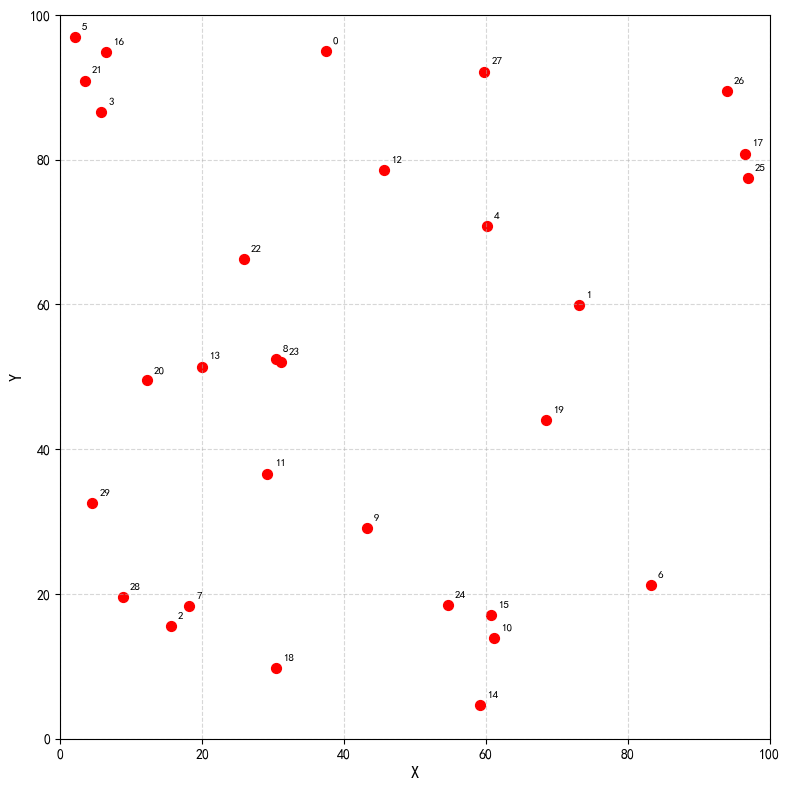

In [7]:
plot_cities(cities)

## 算法调用模块
- 考虑不同算法进行调整时如何实现，如模拟退火调参、遗传算法调整交叉规则等

### 模拟退火算法

#### _new_route 函数：采用 2-opt 策略，在原路径中随机选择两个切分点，将中间部分的路径进行反转，生成新的路径。

In [8]:
def _new_route(route):
    """
    随机选择两个索引，将这两点之间的城市顺序逆转
    """
    new_route = route.copy()
    i, j = np.random.choice(len(route), 2, replace=False) # 随机选择两个切分点
    if i > j:
        i, j = j, i # 确保 i < j
    new_route[i:j+1] = new_route[i:j+1][::-1] # 逆序
    return new_route

#### SA 函数：模拟退火算法的实现

In [40]:
def SA(dist_mat, T0=1000.0, T_min=1e-3, alpha=0.95, iter=100,frozen = 30):
    """
    模拟退火算法
    dist_mat: 距离矩阵
    T0: 初始温度
    T_min: 终止温度
    alpha: 降温系数
    iter: 每个温度下的迭代次数
    frozen: 连续frozen个不同温度没有接受新解，则停止
    """
    np.random.seed(42)
    random.seed(42)
    num = len(dist_mat)
    route = np.random.permutation(num) # 随机生成初始路径
    dist = _route_dist(route, dist_mat) # 计算初始解的路径长度
    best_route = route.copy() # 记录全局最优解
    best_dist = dist
    first = 0 # 记录第一次到达最优解的迭代次数
    history = [] # 记录每个温度下的最优解
    T = T0 # 初始温度
    frozen_count = 0
    temp = 0
    
    while T > T_min and frozen_count <= frozen:
        temp += 1
        accepted = 0
        for _ in range(iter):
            new_route = _new_route(route)
            new_dist = _route_dist(new_route, dist_mat)
            delta = new_dist - dist # dE
            # 接受准则
            if delta < 0:
                route = new_route
                dist = new_dist
                accepted += 1
                if dist < best_dist:
                    best_dist = dist # 更新全局最优解
                    best_route = route.copy()
                    first = temp
                    first_T = T
            else:
                prob = math.exp(-delta / T) # 以一定概率接受
                if np.random.rand() < prob:
                    route = new_route
                    dist = new_dist
                    accepted += 1
        history.append(best_dist) # 当前温度下的最优解
        T *= alpha
        if accepted == 0:
            frozen_count += 1
        else:
            frozen_count = 0
    # if frozen_count >= frozen:
    #     print(f"连续 {frozen_count} 次降温未接受新解.")
    # else:
    #     print(f"温度降至最低阈值 {T_min}.")
    return best_route, best_dist, history,first,first_T

#### 模拟退火调参
- 初始温度T0：决定了初期跳出局部最优的能力
- 降温系数$\alpha$：温度下降的速度。$\alpha$越接近1，温度下降越慢，搜索越细致，但耗时长
- iter：每个温度下的迭代次数


#### estimate_T0 函数：用课件上的方法估计初始温度T0
- 先随机生成一批样本，计算它们的路径距离
- 计算路径距离的最大值与最小值之差 $\delta$
- 根据设定的初始接受概率$P_0$，根据 Metropolis 公式反推：$ T_0 = - \frac{\delta}{ln(P_0)}$

In [10]:
def estimate_T0(dist_mat, sample_size=100, P0=0.9):
    """
    dist_mat: 距离矩阵
    sample_size: 采样的样本数量
    P0: 期望的初始接受概率
    """
    np.random.seed(42)
    random.seed(42)
    num = len(dist_mat)
    distances = []
    for _ in range(sample_size):
        route = np.random.permutation(num) # 随机生成一条路径
        dist = _route_dist(route, dist_mat)
        distances.append(dist)
    delta = max(distances) - min(distances)
    if delta == 0:
        delta = 1e-4
    t0 = -delta / math.log(P0) # t0 = - delta/ ln(P0)
    return t0

In [11]:
est_T0 = estimate_T0(dist_mat)
print(f"估计的初始温度 T0: {est_T0:.2f}")

估计的初始温度 T0: 5566.37


#### tune_SA 函数：通过网格搜索，对模拟退火算法调参

In [41]:
def tune_SA(dist_mat):
    """
    寻找模拟退火算法的最佳参数组合
    记录不同参数下的耗时和最短距离
    """
    T0_candidates = [5,50,200,500,5000]  # 初始温度
    alpha_candidates = [0.90, 0.95, 0.99]   # 降温系数
    iter_candidates = [10,50,100]           # 每个温度下迭代次数
    T_min = 0.1 
    results = []
    
    print("-" * 65)
    print(f"{'T0':<8} | {'alpha':<10} | {'iter':<10} | {'最短距离':<10} | {'耗时(秒)':<10}")
    print("-" * 65)
    
    best_dist_all = float('inf')
    best_params = {}

    # iterations = (len(T0_candidates) * len(alpha_candidates) * len(iter_candidates))
    # with tqdm(total=iterations, desc="SA调参进度", unit="组") as pbar:
    for T0 in T0_candidates:
        for alpha in alpha_candidates:
            for inner_iter in iter_candidates:
                np.random.seed(42) 
                random.seed(42)
                start = time.time()
                _, best_dist, _, _ ,_= SA(dist_mat, T0=T0, T_min=T_min, alpha=alpha, iter=inner_iter)
                end = time.time()
                cost = end - start
                print(f"{T0:<10} | {alpha:<12} | {inner_iter:<12} | {best_dist:<12.2f} | {cost:<10.4f}")
                results.append({
                    'T0': T0,
                    'alpha': alpha,
                    'iter': inner_iter,
                    '最短距离': round(best_dist, 2),
                    '耗时(秒)': round(cost, 4)
                })
                if best_dist < best_dist_all:
                    best_dist_all = best_dist
                    best_params = {'T0': T0, 'alpha': alpha, 'iter': inner_iter}
                #pbar.update(1)
    print("-" * 65)
    print(f"最佳参数: T0={best_params['T0']}, alpha={best_params['alpha']}, iter={best_params['iter']}")
    print(f"最短距离: {best_dist_all:.2f}")
    results = pd.DataFrame(results)
    return results, best_params

In [42]:
df_sa, params_sa = tune_SA(dist_mat)
# 打印最优的前8个参数组合
display(df_sa.sort_values(by=['最短距离', '耗时(秒)'], ascending=[True, True]).head(8))

-----------------------------------------------------------------
T0       | alpha      | iter       | 最短距离       | 耗时(秒)     
-----------------------------------------------------------------
5          | 0.9          | 10           | 621.27       | 0.0070    
5          | 0.9          | 50           | 471.05       | 0.0300    
5          | 0.9          | 100          | 458.53       | 0.0581    
5          | 0.95         | 10           | 536.81       | 0.0120    
5          | 0.95         | 50           | 458.53       | 0.0581    
5          | 0.95         | 100          | 459.89       | 0.1307    
5          | 0.99         | 10           | 458.53       | 0.0650    
5          | 0.99         | 50           | 453.90       | 0.3120    
5          | 0.99         | 100          | 451.77       | 0.6346    
50         | 0.9          | 10           | 559.15       | 0.0110    
50         | 0.9          | 50           | 462.77       | 0.0480    
50         | 0.9          | 100          | 469.6

,T0,alpha,iter,最短距离,耗时(秒)
13,50,0.95,50,451.77,0.1120
24,200,0.99,10,451.77,0.1329
14,50,0.95,100,451.77,0.1930
8,5,0.99,100,451.77,0.6346
34,500,0.99,50,451.77,0.7026
26,200,0.99,100,451.77,1.2293
35,500,0.99,100,451.77,1.4040
40,5000,0.95,50,453.90,0.1750


In [43]:
# 同样打印最差的后8个参数组合
display(df_sa.sort_values(by=['最短距离', '耗时(秒)'], ascending=[True, True]).tail(8))

,T0,alpha,iter,最短距离,耗时(秒)
39,5000,0.95,10,508.44,0.0338
30,500,0.95,10,517.36,0.0280
3,5,0.95,10,536.81,0.0120
18,200,0.90,10,550.07,0.0130
27,500,0.90,10,550.75,0.0150
9,50,0.90,10,559.15,0.0110
36,5000,0.90,10,591.40,0.0210
0,5,0.90,10,621.27,0.0070


- 根据最优参数组合运行

In [44]:
SA_best_route, SA_best_dist, SA_history, SA_first,SA_T = SA(
    dist_mat, 
    T0=50, 
    T_min=0.1, 
    alpha=0.95, 
    iter=50
)
print(f"SA 算法找到的最短路径长度: {SA_best_dist:.2f}")
print(f"SA 首次达到最优解的迭代次数: {SA_first}, SA 首次达到最优解的温度: {SA_T}")
print(f"SA 算法找到的最短路径: {SA_best_route}")
print(f"SA 历史最优路径: {SA_history}")


SA 算法找到的最短路径长度: 451.77
SA 首次达到最优解的迭代次数: 109, SA 首次达到最优解的温度: 0.19639000244067384
SA 算法找到的最短路径: [ 9 11 18  7  2 28 29 20 13  8 23 22  3 21  5 16  0 12  4 27 26 17 25  1
 19  6 14 10 15 24]
SA 历史最优路径: [1436.2623215643762, 1201.4578151937944, 1155.317282260422, 1111.7892453105567, 983.7204726923298, 981.7587044332872, 943.9782036368051, 943.9782036368051, 943.9782036368051, 943.9782036368051, 943.9782036368051, 943.9782036368051, 943.9782036368051, 943.9782036368051, 923.8668546374504, 923.8668546374504, 923.8668546374504, 923.8668546374504, 897.0415286403953, 843.905153090428, 843.905153090428, 843.905153090428, 817.1392831314432, 766.9131507676952, 741.5877463049698, 691.1297375276268, 691.1297375276268, 691.1297375276268, 691.1297375276268, 691.1297375276268, 691.1297375276268, 663.2572833637746, 645.4973686110623, 609.3718804439209, 609.3718804439209, 609.3718804439209, 609.3718804439209, 609.3718804439209, 609.3718804439209, 609.3718804439209, 602.6368795116532, 517.3274929927001, 506

### 遗传算法

#### _ox_crossover 和 _obx_crossover 函数：不同的交叉算法

In [16]:
def _ox_crossover(parent1, parent2):
    """
    Order Crossover
    随机截取父代1的一段基因给子代，然后按父代2的顺序填补剩下的空缺。
    """
    size = len(parent1)
    p1, p2 = np.sort(np.random.choice(size, 2, replace=False))
    child = np.full(size, -1) # 初始化子代，用 -1 占位
    child[p1:p2+1] = parent1[p1:p2+1] # 父代1的片段
    pos = (p2 + 1) % size # 子代中的位置
    p2_idx = (p2 + 1) % size # 父代2中的位置
    
    while -1 in child:
        if parent2[p2_idx] not in child:
            # 如果父代2当前位置的城市不在子代中
            child[pos] = parent2[p2_idx] # 把该城市放到子代的当前位置pos
            pos = (pos + 1) % size
        p2_idx = (p2_idx + 1) % size
        
    return child

In [17]:
def _obx_crossover(parent1, parent2):
    """
    Order-Based Crossover
    从父代1中随机选择一组城市，在父代2中找到这些城市并清空，
    然后按它们在父代1中的出现顺序，依次填入父代2的空位中。
    """
    size = len(parent1)
    num = np.random.randint(1, size)
    
    # 在父代1中随机挑选 num 个索引，并按从小到大排序
    idx = np.sort(np.random.choice(size, num, replace=False))
    selected = parent1[idx]
    child = parent2.copy()
    empty_pos = []
    
    for i in range(size):
        if child[i] in selected:
            empty_pos.append(i) # 记录空位索引
    
    for i, pos in enumerate(empty_pos):
        child[pos] = selected[i] # 按父代1的顺序填入
        
    return child

#### _swap_mutate 和 _inverse_mutate 函数：不同的变异算法

In [18]:
def _swap_mutate(route, pm):
    """
    变异操作：以概率 pm 随机交换两个城市的位置
    """
    if np.random.rand() < pm:
        i, j = np.random.choice(len(route), 2, replace=False)
        route[i], route[j] = route[j], route[i]
    return route

In [19]:
def _inverse_mutate(route, pm):
    """
    变异操作：以概率 pm 随机翻转路径的某部分
    """
    if np.random.rand() < pm:
        i, j = np.random.choice(len(route), 2, replace=False)
        if i > j:
            i, j = j, i
        route[i:j+1] = route[i:j+1][::-1]
    return route

#### _*_selection 函数：四种不同的选择策略

In [20]:
def _default_selection(population, fitness, pop_size):
    """
    根据适应度计算被选中的概率
    """
    probs = fitness / fitness.sum()
    selected_idx = np.random.choice(pop_size, size=pop_size, p=probs)
    selected = [population[i].copy() for i in selected_idx]
    return selected

In [21]:
def _truncation_selection(population, fitness, pop_size, T=0.5):
    """
    选取种群中适应度排名前 T% 的个体，并将它们复制多次以填满新种群。
    """
    size = max(1, int(pop_size * T))
    rank = np.argsort(fitness)[::-1]
    idx = rank[:size]
    selected = []
    for i in range(pop_size):
        selected.append(population[idx[i % size]].copy())
    return selected

In [22]:
def _tournament_selection(population, fitness, pop_size, k=3):
    """
    每次随机从种群中抽出 k 个个体，将其中适应度最高的个体放入子代。重复 pop_size 次。
    """
    selected = []
    for _ in range(pop_size):
        candidates= np.random.choice(pop_size, size=k, replace=False)
        best = candidates[np.argmax(fitness[candidates])]
        selected.append(population[best].copy())
    return selected

In [23]:
def _ranking_selection(population, fitness, pop_size,q = 0.99):
    """
    按照适应度排名赋予选择概率
    """
    idx = np.argsort(fitness)[::-1]
    weights = np.zeros(pop_size)
    for rank, idx in enumerate(idx):
        weights[idx] = q ** (rank-1) # exponential ranking
    probs = weights / weights.sum()
    selected_idx = np.random.choice(pop_size, size=pop_size, p=probs, replace=True)
    selected = [population[i].copy() for i in selected_idx]
    
    return selected

#### GA 函数：运行单次遗传算法的主函数

In [26]:
def GA(dist_mat, pop_size=50, generations=800, pc=0.9, pm=0.2,
       selection_method='tournament', crossover_method='obx', mutation_method='inverse',
       stop=80):
    """
    遗传算法主函数
    pop_size: 种群规模
    generations: 繁衍代数
    pc: 交叉概率
    pm: 变异概率
    selection_method: 选择策略，包括'truncation', 'tournament', 'ranking', 'default'
    crossover_method: 交叉策略，包括'ox', 'obx'
    mutation_method: 变异策略，包括'inverse', 'swap'
    stop: 最优解连续 stop 代不更新则提前停止（None 表示不提前停止）
    """
    np.random.seed(42)
    random.seed(42)
    num = len(dist_mat)
    population = [np.random.permutation(num) for _ in range(pop_size)]  # 生成 pop_size 个初始解
    best_route = None
    best_dist = float('inf')
    first = 0
    history = []
    count = 0

    for gen in range(generations):
        distances = np.array([_route_dist(ind, dist_mat) for ind in population])
        fitness = 1.0 / (distances + 1e-6)  # 距离的倒数作为适应度
        min_idx = np.argmin(distances)
        improved = False
        if distances[min_idx] < best_dist:
            best_dist = distances[min_idx]
            best_route = population[min_idx].copy()
            improved = True
            first = gen + 1
        history.append(best_dist)

        # 早停：最优解连续若干代不更新
        if improved:
            count = 0
        else:
            count += 1
            if (stop is not None) and (count >= stop):
                break

        if selection_method == 'truncation':
            selected = _truncation_selection(population, fitness, pop_size, T=0.5)
        elif selection_method == 'tournament':
            selected = _tournament_selection(population, fitness, pop_size, k=3)
        elif selection_method == 'ranking':
            selected = _ranking_selection(population, fitness, pop_size)
        elif selection_method == 'default':
            selected = _default_selection(population, fitness, pop_size)
        else:
            raise ValueError("No such selection method!")

        new_pop = [best_route.copy()]  # 精英保留
        for i in range(1, pop_size, 2):
            parent1 = selected[i]
            parent2 = selected[(i + 1) % pop_size]

            # 交叉
            if np.random.rand() < pc:
                if crossover_method == "ox":
                    child1 = _ox_crossover(parent1, parent2)
                    child2 = _ox_crossover(parent2, parent1)
                elif crossover_method == "obx":
                    child1 = _obx_crossover(parent1, parent2)
                    child2 = _obx_crossover(parent2, parent1)
                else:
                    raise ValueError("No such crossover method!")
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            # 变异
            if mutation_method == 'inverse':
                child1 = _inverse_mutate(child1, pm)
                child2 = _inverse_mutate(child2, pm)
            elif mutation_method == "swap":
                child1 = _swap_mutate(child1, pm)
                child2 = _swap_mutate(child2, pm)
            else:
                raise ValueError("No such mutation method!")

            new_pop.extend([child1, child2])

        population = new_pop[:pop_size]  # 保持种群规模不变，截断多余的

    # 记录最后一代
    distances = np.array([_route_dist(ind, dist_mat) for ind in population])
    min_idx = np.argmin(distances)
    if distances[min_idx] < best_dist:
        best_dist = distances[min_idx]
        best_route = population[min_idx].copy()
    if (len(history) == 0) or (history[-1] != best_dist):
        history.append(best_dist)

    return best_route, best_dist, history, first

#### tune_GA 函数：对遗传算法的参数和规则进行调优

In [ ]:
def tune_GA(dist_mat):
    """
    遗传算法参数与规则的网格搜索
    """
    generations = 800 
    pop_sizes = [50, 100, 200]
    pc_rates = [0.7, 0.9]
    pm_rates = [0.05, 0.2]
    selection_methods = ['default', 'truncation', 'tournament', 'ranking'] 
    crossover_methods = ['ox', 'obx']
    mutation_methods = ['swap', 'inverse']
    results = []
    best_dist_all = float('inf')
    best_params = {}
    iterations = (len(pop_sizes) * len(pc_rates) * len(pm_rates) * len(selection_methods) * len(crossover_methods) * len(mutation_methods))

    with tqdm(total=iterations, desc="GA调参进度", unit="组") as pbar:
        for pop in pop_sizes:
            for pc in pc_rates:
                for pm in pm_rates:
                    for sel in selection_methods:
                        for cross in crossover_methods:
                            for mut in mutation_methods:
                                start = time.time() # 起始时间
                                _, best_dist, _, _ = GA(
                                    dist_mat, pop_size=pop, generations=generations, 
                                    pc=pc, pm=pm, 
                                    selection_method=sel, crossover_method=cross, mutation_method=mut
                                ) 
                                cost = time.time() - start # 计算耗时
                                results.append({
                                    '种群规模': pop, '交叉率': pc, '变异率': pm,
                                    '选择策略': sel, '交叉策略': cross, '变异策略': mut,
                                    '最短距离': round(best_dist, 2),
                                    '耗时(秒)': round(cost, 3)
                                })
                                if best_dist < best_dist_all:
                                    best_dist_all = best_dist
                                    best_params = {
                                        'pop_size': pop, 'pc': pc, 'pm': pm,
                                        'selection': sel, 'crossover': cross, 'mutation': mut
                                    }
                                pbar.update(1)

    results = pd.DataFrame(results)
    print(f"GA最佳参数组合: 种群={best_params['pop_size']}, pc={best_params['pc']}, pm={best_params['pm']}, "
          f"选择={best_params['selection']}, 交叉={best_params['crossover']}, 变异={best_params['mutation']}")
    print(f"GA最短距离: {best_dist_all:.2f}")
    
    return results, best_params

In [ ]:
df_ga, params_ga = tune_GA(dist_mat) # GA的调参组合较多，速度较慢

In [27]:
#df_ga.to_csv("GA.csv", index=False) 
#df_ga = pd.read_csv("GA.csv")
display(df_ga.sort_values(by=['最短距离', '耗时(秒)'], ascending=[True, True]).head(8)) # 最优的前8个参数组合
display(df_ga.sort_values(by=['最短距离', '耗时(秒)'], ascending=[True, True]).tail(8)) # 最差的后8个参数组合

,种群规模,交叉率,变异率,选择策略,交叉策略,变异策略,最短距离,耗时(秒)
59,50,0.9,0.20,tournament,obx,inverse,451.77,3.741
71,100,0.7,0.05,truncation,obx,inverse,451.77,4.602
67,100,0.7,0.05,default,obx,inverse,451.77,5.567
107,100,0.9,0.05,tournament,obx,inverse,451.77,5.653
119,100,0.9,0.20,truncation,obx,inverse,451.77,6.315
105,100,0.9,0.05,tournament,ox,inverse,451.77,6.898
183,200,0.9,0.20,truncation,obx,inverse,451.77,11.730
171,200,0.9,0.05,tournament,obx,inverse,451.77,11.805


,种群规模,交叉率,变异率,选择策略,交叉策略,变异策略,最短距离,耗时(秒)
63,50,0.9,0.20,ranking,obx,inverse,741.43,3.669
161,200,0.9,0.05,default,ox,inverse,752.12,16.782
114,100,0.9,0.20,default,obx,swap,760.38,6.147
177,200,0.9,0.20,default,ox,inverse,775.14,16.575
96,100,0.9,0.05,default,ox,swap,808.20,8.372
47,50,0.9,0.05,ranking,obx,inverse,808.90,3.265
62,50,0.9,0.20,ranking,obx,swap,825.44,3.082
112,100,0.9,0.20,default,ox,swap,847.08,10.206


In [28]:
GA_best_route,GA_best_dist,GA_history,GA_first = GA(dist_mat,pop_size=50,pc=0.9,pm=0.2,selection_method='tournament',crossover_method='obx',mutation_method='inverse')
print(f"GA 算法找到的最短路径长度: {GA_best_dist:.2f}")
print(f"GA 首次达到最优解的迭代次数: {GA_first}")
print(f"GA 算法找到的最短路径: {GA_best_route}")
print(f"GA 历史最优路径: {GA_history}")

GA 算法找到的最短路径长度: 451.77
GA 首次达到最优解的迭代次数: 102
GA 算法找到的最短路径: [25 17 26 27  4 12  0 16  5 21  3 22 23  8 13 20 29 28  2  7 18 11  9 24
 15 10 14  6 19  1]
GA 历史最优路径: [1353.8361645788154, 1296.254154994302, 1269.5204978538147, 1269.5204978538147, 1269.5204978538147, 1269.5204978538147, 1141.837888874248, 1115.6325021093735, 1109.1565877871717, 1109.1565877871717, 1062.3293029088552, 1015.9031007398564, 1015.9031007398564, 969.0558835381494, 945.3052112104543, 834.3174617902444, 834.3174617902444, 767.5469772163473, 767.5469772163473, 767.5469772163473, 767.5469772163473, 767.5469772163473, 752.3197534524815, 747.0321092364007, 720.3013992624075, 715.7881894126261, 652.4512046971688, 652.4512046971688, 649.951648935032, 636.9288390049691, 626.5214412632225, 608.9690801226851, 595.4449068727457, 591.7392990499517, 591.7392990499517, 591.7392990499517, 591.7392990499517, 579.0228560736455, 579.0228560736455, 579.0228560736455, 575.3172482508514, 575.3172482508514, 575.3172482508514, 575.317248

## 结果输出模块

#### plot_res 函数：画出最终环路图和迭代收敛曲线

In [47]:
def plot_res(cities, best_route, history, first=None, first_T=None, algorithm="Algorithm"):
    """
    可视化：最终环路图和迭代收敛曲线
    """
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.set_title(f"{algorithm}")
    ax1.scatter(cities[:, 0], cities[:, 1], c='red', marker='o', s=50, zorder=5)
    for i, (x, y) in enumerate(cities):
        ax1.annotate(str(i), (x+1, y+1), fontsize=10)
    route = cities[best_route]
    route = np.vstack((route, route[0]))
    ax1.plot(route[:, 0], route[:, 1], c='blue', linestyle='-', zorder=4)
    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 100)
    ax1.grid(True)
    start_x, start_y = cities[best_route[0]]
    ax1.scatter(start_x, start_y, c='red', marker='*', s=200, zorder=6, linewidths=1.5, label="起点")
    ax1.legend(loc='upper right')

    fig, ax2 = plt.subplots(figsize=(6, 4))
    ax2.set_title(f"{algorithm}")
    ax2.plot(history, c='green', linewidth=2)
    ax2.set_xlabel("迭代次数")
    ax2.set_ylabel("最优路径长度")
    ax2.grid(True)

    if first is not None and len(history) > 0:
        first_idx = int(first) - 1
        if 0 <= first_idx < len(history):
            first_value = history[first_idx]
            if algorithm == "SA" and first_T is not None:
               ax2.axvline(first, c='red', linestyle='--', linewidth=1.5, label=f"首次达到最优解: {first}\n温度: {first_T:.2f}") 
            else:
                ax2.axvline(first, c='red', linestyle='--', linewidth=1.5, label=f"首次达到最优解: {first}")
            ax2.legend(loc='best')
    plt.tight_layout()
    plt.show()


- 画出模拟退火算法的图像

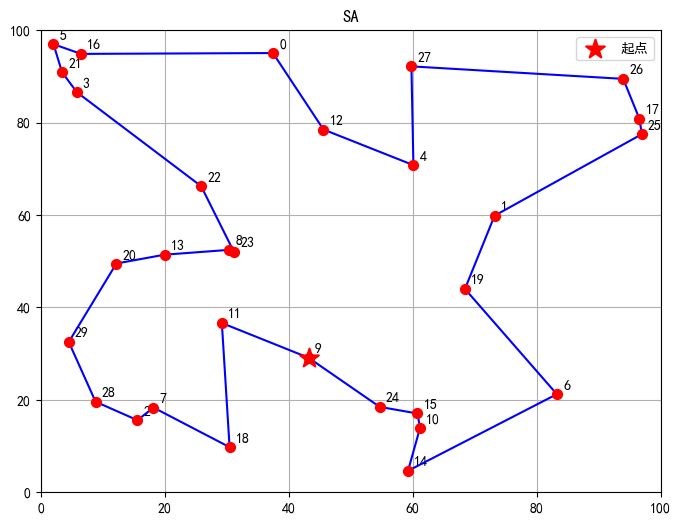

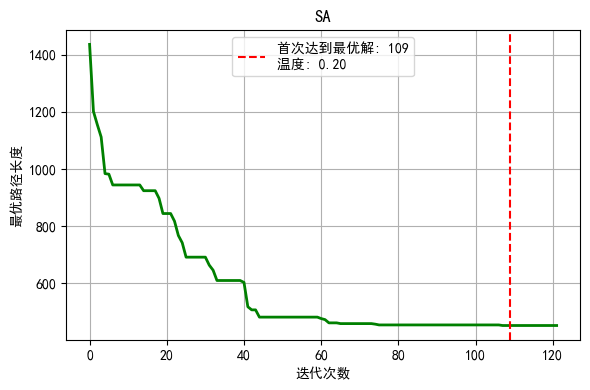

In [48]:
plot_res(cities, SA_best_route, SA_history, SA_first,SA_T,algorithm="SA")


- 画出遗传算法的图像

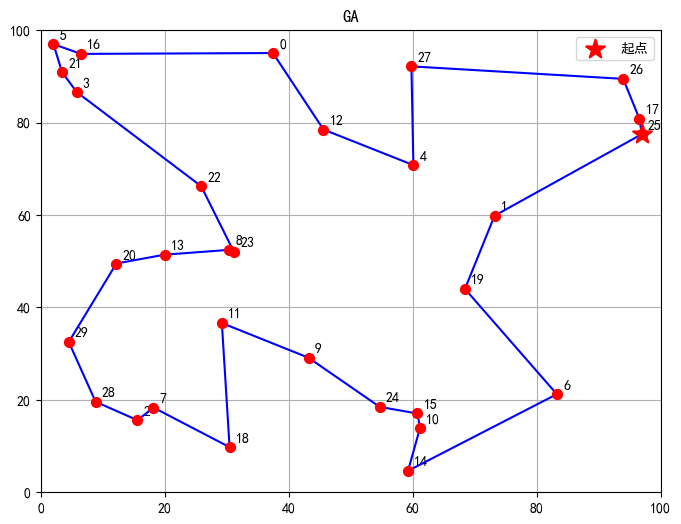

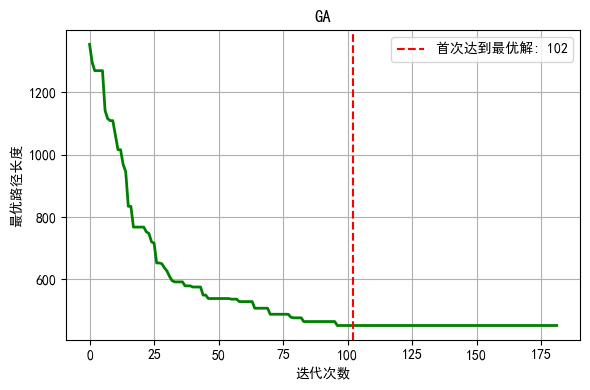

In [49]:
plot_res(cities, GA_best_route, GA_history, GA_first, algorithm="GA")


#### animate 函数：动画展示模拟退火算法并保存

In [41]:
def animate_SA(cities, dist_mat,filename,T0=50, T_min=0.1, alpha=0.95,iter=50):
    """
    动画展示模拟退火算法
    """
    num = len(dist_mat)
    route = np.random.permutation(num)
    dist = _route_dist(route, dist_mat)
    best_route = route.copy()
    best_dist = dist
    T = T0
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.scatter(cities[:, 0], cities[:, 1], c='red', marker='o', s=50, zorder=5)
    for i, (x, y) in enumerate(cities):
        ax.annotate(str(i), (x+1, y+1), fontsize=8)
    line, = ax.plot([], [], 'b-', linewidth=1.5, zorder=4)
    text_info = ax.text(
        80, 5, "", fontsize=12, color='black', weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8)
    )
    
    def run():
        nonlocal T, route, dist, best_route, best_dist
        iteration = 0
        
        while T > T_min:
            for _ in range(iter):
                new_route = _new_route(route) 
                new_dist = _route_dist(new_route, dist_mat)
                delta = new_dist - dist
                if delta < 0 or np.random.rand() < math.exp(-delta / T):
                    route = new_route
                    dist = new_dist
                    if dist < best_dist:
                        best_dist = dist
                        best_route = route.copy()

            T *= alpha
            iteration += 1
            yield best_route.copy(), best_dist, T, iteration

        yield best_route.copy(), best_dist, T, iteration

    def update(data):
        route, dist, current_temp, iteration = data
        route_cities = cities[route]
        route_cities = np.vstack((route_cities, route_cities[0]))
        line.set_data(route_cities[:, 0], route_cities[:, 1])
        text_info.set_text(f"迭代次数: {iteration}\n当前温度: {current_temp:.2f}\n最短距离:{dist:.2f}")
        return line, text_info
    ani = animation.FuncAnimation(
        fig, update, frames=run, 
        interval=50, blit=True, 
        repeat=False,cache_frame_data=False
    )
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    writer = animation.PillowWriter(fps=7) 
    ani.save(filename, writer=writer)
    plt.close(fig)
    print(f"动画已保存为 {filename}")

In [42]:
animate_SA(cities, dist_mat,filename="SA.gif",T0=50, T_min=0.1, alpha=0.95, iter=50)   

动画已保存为 SA.gif


#### animate_GA 函数：动画展示遗传算法并保存

In [51]:
def animate_GA(cities, dist_mat, filename,
               pop_size=50, generations=800,
               pc=0.9, pm=0.2,
               selection_method='tournament', crossover_method='obx', mutation_method='inverse', stop=80):
    """
    动画展示遗传算法
    """
    np.random.seed(42)
    random.seed(42)
    num = len(dist_mat)
    population = [np.random.permutation(num) for _ in range(pop_size)]
    best_route = None
    best_dist = float('inf')
    count = 0

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.scatter(cities[:, 0], cities[:, 1], c='red', marker='o', s=50, zorder=5)
    for i, (x, y) in enumerate(cities):
        ax.annotate(str(i), (x + 1, y + 1), fontsize=8)
    line, = ax.plot([], [], 'b-', linewidth=1.5, zorder=4)
    text_info = ax.text(
        74, 5, "", fontsize=12, color='black', weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8)
    )

    def run():
        nonlocal population, best_route, best_dist, count
        last_gen = 0

        for gen in range(1, generations + 1):
            last_gen = gen
            distances = np.array([_route_dist(ind, dist_mat) for ind in population])
            fitness = 1.0 / (distances + 1e-6)
            min_idx = np.argmin(distances)
            improved = False

            if distances[min_idx] < best_dist:
                best_dist = distances[min_idx]
                best_route = population[min_idx].copy()
                improved = True

            yield best_route.copy(), best_dist, gen

            # 早停
            if improved:
                count = 0
            else:
                count += 1
                if (stop is not None) and (count >= stop):
                    break

            if selection_method == 'truncation':
                selected = _truncation_selection(population, fitness, pop_size, T=0.5)
            elif selection_method == 'tournament':
                selected = _tournament_selection(population, fitness, pop_size, k=3)
            elif selection_method == 'ranking':
                selected = _ranking_selection(population, fitness, pop_size)
            elif selection_method == 'default':
                selected = _default_selection(population, fitness, pop_size)
            else:
                raise ValueError("No such selection method!")

            new_pop = [best_route.copy()]  # 精英保留
            for i in range(1, pop_size, 2):
                parent1 = selected[i]
                parent2 = selected[(i + 1) % pop_size]

                if np.random.rand() < pc:
                    if crossover_method == 'ox':
                        child1 = _ox_crossover(parent1, parent2)
                        child2 = _ox_crossover(parent2, parent1)
                    elif crossover_method == 'obx':
                        child1 = _obx_crossover(parent1, parent2)
                        child2 = _obx_crossover(parent2, parent1)
                    else:
                        raise ValueError("No such crossover method!")
                else:
                    child1, child2 = parent1.copy(), parent2.copy()

                if mutation_method == 'inverse':
                    child1 = _inverse_mutate(child1, pm)
                    child2 = _inverse_mutate(child2, pm)
                elif mutation_method == 'swap':
                    child1 = _swap_mutate(child1, pm)
                    child2 = _swap_mutate(child2, pm)
                else:
                    raise ValueError("No such mutation method!")

                new_pop.extend([child1, child2])

            population = new_pop[:pop_size]

        distances = np.array([_route_dist(ind, dist_mat) for ind in population])
        min_idx = np.argmin(distances)
        if distances[min_idx] < best_dist:
            best_dist = distances[min_idx]
            best_route = population[min_idx].copy()

        yield best_route.copy(), best_dist, last_gen

    def update(data):
        route, dist, gen = data
        route_cities = cities[route]
        route_cities = np.vstack((route_cities, route_cities[0]))
        line.set_data(route_cities[:, 0], route_cities[:, 1])
        text_info.set_text(f"代数: {gen}\n最短距离: {dist:.2f}")
        return line, text_info

    ani = animation.FuncAnimation(
        fig, update, frames=run,
        interval=60, blit=True,
        repeat=False, cache_frame_data=False
    )

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    writer = animation.PillowWriter(fps=9)
    ani.save(filename, writer=writer)
    plt.close(fig)
    print(f"动画已保存为 {filename}")

In [52]:
animate_GA(
    cities, dist_mat,
    filename="GA.gif",
    pop_size=50,
    generations=300,
    pc=0.9,
    pm=0.2,
    selection_method='tournament',
    crossover_method='obx',
    mutation_method='inverse',
    stop = 50
)

动画已保存为 GA.gif


- 对比 SA 算法最优参数组合和 GA 算法最优参数组合的计算效率和性能，两者都达到了最短距离，但 SA 算法的耗时显著少于 GA 算法。

In [37]:
sa_best = df_sa.sort_values(by=['最短距离', '耗时(秒)'], ascending=[True, True]).head(1)[['最短距离', '耗时(秒)']].copy()
ga_best = df_ga.sort_values(by=['最短距离', '耗时(秒)'], ascending=[True, True]).head(1)[['最短距离', '耗时(秒)']].copy()
sa_best.insert(0, '首次达到最优解的迭代次数', SA_first)
ga_best.insert(0, '首次达到最优解的迭代次数', GA_first)
sa_best.insert(0, '算法', 'SA')
ga_best.insert(0, '算法', 'GA')
compare = pd.concat([sa_best, ga_best], ignore_index=True)
display(compare)

,算法,首次达到最优解的迭代次数,最短距离,耗时(秒)
0,SA,109,451.77,0.107
1,GA,102,451.77,3.741
